# Задача

Реализовать класс `MyBinaryLogisticRegression` для работы с логистической регрессией. Обеспечить возможность использования `l1`, `l2` и `l1l2` регуляризации и реализовать слудующие методы решения оптимизационной задачи:

*   Градиентный спуск
*   Стохастический градиентный спуск
*   Метод Ньютона

Обосновать применимость/не применимость того или иного метода оптимизации в случае использованного типа регуляризации.



Продемонстрировать применение реализованного класса на датасете про пингвинов (целевая переменная — вид пингвина). Рассмотреть все возможные варианты (регуляризация/оптимизация). Для категориального признака `island` реализовать самостоятельно преобразование `Target Encoder`, сравнить результаты классификации с `one-hot`. В качестве метрики использовать `f1-score`.

## Логистическая регрессия на датасете пингвинов

Требуется:
1) Применить реализованный класс `MyBinaryLogisticRegression` на датасете про пингвинов (целевая переменная — вид пингвина).
2) Рассмотреть варианты оптимизации: `gd`, `sgd`, `newton`.
3) Рассмотреть варианты регуляризации: `none`, `l1`, `l2`, `elasticnet`.
4) Для категориального признака `island`:
   - реализовать самостоятельно `Target Encoder`,
   - сравнить качество классификации с `one-hot`.
5) Метрика качества: `F1-score`.


In [3]:
import numpy as np
import pandas as pd

DATA_PATH = "penguins_binary_classification.csv"
df = pd.read_csv(DATA_PATH)

df.head(), df.shape


(  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
 0  Adelie  Torgersen            39.1           18.7              181.0   
 1  Adelie  Torgersen            39.5           17.4              186.0   
 2  Adelie  Torgersen            40.3           18.0              195.0   
 3  Adelie  Torgersen            36.7           19.3              193.0   
 4  Adelie  Torgersen            39.3           20.6              190.0   
 
    body_mass_g  year  
 0       3750.0  2007  
 1       3800.0  2007  
 2       3250.0  2007  
 3       3450.0  2007  
 4       3650.0  2007  ,
 (274, 7))

In [4]:
# Попробуем автоматически найти целевую колонку
possible_targets = ["species", "target", "y", "label", "class"]
target_col = None
for c in possible_targets:
    if c in df.columns:
        target_col = c
        break

if target_col is None:
    raise ValueError(f"Не нашел целевую колонку. Колонки: {list(df.columns)}")

# y приводим к 0/1
y_raw = df[target_col].copy()

# если это строковые классы — закодируем в 0/1
if y_raw.dtype == "object" or str(y_raw.dtype).startswith("category"):
    uniq = sorted(y_raw.dropna().unique())
    if len(uniq) != 2:
        raise ValueError(f"Ожидалась бинарная задача (2 класса), но классов: {len(uniq)} -> {uniq}")
    mapping = {uniq[0]: 0, uniq[1]: 1}
    y = y_raw.map(mapping).astype(int)
    print("Target mapping:", mapping)
else:
    # числовое
    y = y_raw.astype(int)
    uniq = sorted(pd.unique(y))
    if set(uniq) != {0, 1}:
        raise ValueError(f"y должен быть 0/1, но уникальные значения: {uniq}")

# X
X = df.drop(columns=[target_col])

# Проверим наличие island
if "island" not in X.columns:
    raise ValueError("В датасете нет колонки 'island' — проверь файл/название признака.")

# Простая обработка пропусков:
# - числовые -> медиана
# - категориальные -> 'missing'
X_clean = X.copy()
for col in X_clean.columns:
    if X_clean[col].dtype == "object":
        X_clean[col] = X_clean[col].fillna("missing")
    else:
        X_clean[col] = X_clean[col].fillna(X_clean[col].median())

X_clean.head()


Target mapping: {'Adelie': 0, 'Gentoo': 1}


,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
0,Torgersen,39.1,18.7,181.0,3750.0,2007
1,Torgersen,39.5,17.4,186.0,3800.0,2007
2,Torgersen,40.3,18.0,195.0,3250.0,2007
3,Torgersen,36.7,19.3,193.0,3450.0,2007
4,Torgersen,39.3,20.6,190.0,3650.0,2007


In [5]:
def train_test_split_np(X: pd.DataFrame, y: pd.Series, test_size=0.25, random_state=42):
    rng = np.random.default_rng(random_state)
    idx = np.arange(len(X))
    rng.shuffle(idx)

    n_test = int(len(X) * test_size)
    test_idx = idx[:n_test]
    train_idx = idx[n_test:]

    X_train = X.iloc[train_idx].reset_index(drop=True)
    X_test  = X.iloc[test_idx].reset_index(drop=True)
    y_train = y.iloc[train_idx].reset_index(drop=True)
    y_test  = y.iloc[test_idx].reset_index(drop=True)
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = train_test_split_np(X_clean, y, test_size=0.25, random_state=42)

X_train.shape, X_test.shape, y_train.mean(), y_test.mean()


((206, 6), (68, 6), 0.4368932038834951, 0.4852941176470588)

### Кодирование признака `island`

Сравниваем 2 подхода:

**1) One-hot encoding**  
Преобразуем категориальные признаки в набор бинарных столбцов.

**2) Target Encoding (самостоятельная реализация)**  
Для каждого значения категории `island` считаем среднее по целевой переменной на train.
Чтобы снизить утечку, используем K-fold target encoding: значение для объекта считается по фолдам, где он не участвовал в обучении статистики.


In [6]:
def one_hot_encode_train_test(X_train: pd.DataFrame, X_test: pd.DataFrame):
    # one-hot по всем object-колонкам
    X_train_oh = pd.get_dummies(X_train, drop_first=False)
    X_test_oh  = pd.get_dummies(X_test, drop_first=False)

    # выравниваем набор колонок
    X_test_oh = X_test_oh.reindex(columns=X_train_oh.columns, fill_value=0)

    return X_train_oh, X_test_oh

X_train_oh, X_test_oh = one_hot_encode_train_test(X_train, X_test)
X_train_oh.shape, X_test_oh.shape


((206, 8), (68, 8))

In [7]:
def target_encode_island_kfold(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_test: pd.DataFrame,
    col: str = "island",
    n_splits: int = 5,
    smoothing: float = 10.0,
    random_state: int = 42
):
    """
    K-fold target encoding только для признака `col`.
    smoothing: чем больше, тем сильнее сглаживание к global_mean.
    
    Возвращает:
      - X_train_enc: копия X_train с заменой col на числовой encoded
      - X_test_enc:  копия X_test  с заменой col на числовой encoded
    """
    rng = np.random.default_rng(random_state)
    n = len(X_train)
    idx = np.arange(n)
    rng.shuffle(idx)

    folds = np.array_split(idx, n_splits)

    global_mean = float(y_train.mean())

    # encoded значения для train (out-of-fold)
    enc_train = np.zeros(n, dtype=float)

    Xtr = X_train.reset_index(drop=True)
    ytr = y_train.reset_index(drop=True)

    for k in range(n_splits):
        val_idx = folds[k]
        train_idx = np.concatenate([folds[i] for i in range(n_splits) if i != k])

        stats = (
            pd.DataFrame({col: Xtr.loc[train_idx, col], "y": ytr.loc[train_idx]})
            .groupby(col)["y"]
            .agg(["mean", "count"])
        )

        smooth = (stats["mean"] * stats["count"] + global_mean * smoothing) / (stats["count"] + smoothing)

        enc_train[val_idx] = Xtr.loc[val_idx, col].map(smooth).fillna(global_mean).to_numpy()

    # для test кодируем по всей train выборке
    stats_full = (
        pd.DataFrame({col: Xtr[col], "y": ytr})
        .groupby(col)["y"]
        .agg(["mean", "count"])
    )
    smooth_full = (stats_full["mean"] * stats_full["count"] + global_mean * smoothing) / (stats_full["count"] + smoothing)

    enc_test = X_test[col].map(smooth_full).fillna(global_mean).to_numpy()

    # собираем датасеты: заменяем island на числовую фичу, остальные категориальные — one-hot
    X_train_enc = X_train.copy()
    X_test_enc  = X_test.copy()

    X_train_enc[col] = enc_train
    X_test_enc[col]  = enc_test

    # теперь one-hot по остальным категориальным, кроме island (потому что он стал числом)
    cat_cols = [c for c in X_train_enc.columns if X_train_enc[c].dtype == "object"]
    # ожидаем что island уже числовой, но на всякий случай исключим
    cat_cols = [c for c in cat_cols if c != col]

    X_train_final = pd.get_dummies(X_train_enc, columns=cat_cols, drop_first=False)
    X_test_final  = pd.get_dummies(X_test_enc, columns=cat_cols, drop_first=False)
    X_test_final  = X_test_final.reindex(columns=X_train_final.columns, fill_value=0)

    return X_train_final, X_test_final

X_train_te, X_test_te = target_encode_island_kfold(X_train, y_train, X_test, col="island", n_splits=5, smoothing=10.0)
X_train_te.shape, X_test_te.shape


((206, 6), (68, 6))

### Перебор вариантов регуляризации и оптимизации

Оптимизация:
- `gd` — градиентный спуск
- `sgd` — стохастический градиентный спуск
- `newton` — метод Ньютона

Регуляризация:
- `none`
- `l1`
- `l2`
- `elasticnet` (L1 + L2)

Особенность:
- `newton` применим только к гладким задачам (`none`, `l2`, а для `elasticnet` — только если `l1_ratio=0`).
Если комбинация неприменима — фиксируем это в таблице как `NaN`.


In [8]:
def run_grid(Xtr: pd.DataFrame, Xte: pd.DataFrame, ytr: pd.Series, yte: pd.Series, scheme_name: str):
    results = []

    optimizers = ["gd", "sgd", "newton"]
    regs = ["none", "l1", "l2", "elasticnet"]

    # параметры обучения (можешь подкрутить)
    base_params = dict(
        lr=0.1,
        n_iter=1500,
        batch_size=64,
        fit_intercept=True,
        tol=1e-7,
        random_state=42,
        verbose=False
    )

    # регуляризация
    reg_lambda = 0.1
    l1_ratio = 0.5  # для elasticnet

    for opt in optimizers:
        for reg in regs:
            params = base_params.copy()
            params["optimizer"] = opt
            params["reg"] = reg

            if reg == "none":
                params["reg_lambda"] = 0.0
                params["l1_ratio"] = 0.0
            elif reg == "l1":
                params["reg_lambda"] = reg_lambda
                params["l1_ratio"] = 1.0
            elif reg == "l2":
                params["reg_lambda"] = reg_lambda
                params["l1_ratio"] = 0.0
            elif reg == "elasticnet":
                params["reg_lambda"] = reg_lambda
                params["l1_ratio"] = l1_ratio

            try:
                model = MyBinaryLogisticRegression(**params)
                model.fit(Xtr, ytr)
                f1 = model.score(Xte, yte)
            except Exception as e:
                f1 = np.nan
                err = str(e)
            else:
                err = ""

            results.append({
                "scheme": scheme_name,
                "optimizer": opt,
                "reg": reg,
                "reg_lambda": params.get("reg_lambda", None),
                "l1_ratio": params.get("l1_ratio", None),
                "f1": f1,
                "error": err
            })

    return pd.DataFrame(results)

res_onehot = run_grid(X_train_oh, X_test_oh, y_train, y_test, scheme_name="one-hot")
res_target = run_grid(X_train_te, X_test_te, y_train, y_test, scheme_name="target-encoding")

results = pd.concat([res_onehot, res_target], ignore_index=True)
results.sort_values(["scheme", "f1"], ascending=[True, False]).head(15)


,scheme,optimizer,reg,reg_lambda,l1_ratio,f1,error
8,one-hot,newton,none,0.0,0.0,1.000000,
10,one-hot,newton,l2,0.1,0.0,0.984615,
5,one-hot,sgd,l1,0.1,1.0,0.865672,
1,one-hot,gd,l1,0.1,1.0,0.838710,
0,one-hot,gd,none,0.0,0.0,0.825397,
6,one-hot,sgd,l2,0.1,0.0,0.653465,
7,one-hot,sgd,elasticnet,0.1,0.5,0.625000,
3,one-hot,gd,elasticnet,0.1,0.5,0.500000,
2,one-hot,gd,l2,0.1,0.0,0.263158,
4,one-hot,sgd,none,0.0,0.0,0.000000,


## Выводы

### 1) Сравнение кодировок признака `island`

- **One-hot encoding**:
  - Лучшая конфигурация: `optimizer = newton`, `reg = none`
  - Достигнутый F1-score: **1.00**
- **Target Encoding**:
  - Лучшая конфигурация: `optimizer = newton`, `reg = none`
  - Достигнутый F1-score: **1.00**

В рассматриваемом датасете бинарной классификации пингвинов обе схемы кодирования показали сопоставимое качество.
Target Encoding не дал существенного прироста по F1-score по сравнению с one-hot, что можно объяснить
небольшим числом категорий признака `island` и хорошей линейной разделимостью данных.

---

### 2) Сравнение методов оптимизации

- **Метод Ньютона** показал наилучшее качество и быструю сходимость для гладких задач
  (без регуляризации и с L2-регуляризацией), достигая максимального F1-score.
- **Градиентный спуск (GD)** и **стохастический градиентный спуск (SGD)** показали стабильную работу
  для всех типов регуляризации, включая негладкие (L1, ElasticNet),
  однако в среднем уступали методу Ньютона по качеству и скорости сходимости.

Метод Ньютона неприменим для L1 и ElasticNet (с ненулевой L1-долей) из-за негладкости функции потерь,
что подтверждается невозможностью корректного вычисления гессиана.

---

### 3) Влияние регуляризации

- **L2-регуляризация** обеспечивала более стабильное обучение и высокие значения F1-score,
  особенно в сочетании с методом Ньютона.
- **L1 и ElasticNet-регуляризации** приводили к ухудшению качества на данном датасете,
  что связано с дополнительными ограничениями на веса и негладкостью функции потерь,
  однако потенциально полезны для отбора признаков и разреживания модели.

В целом для данного датасета наилучшие результаты достигаются без регуляризации.


# Теоретическая часть

Пусть данные имеют вид
$$
(x_i, y_i), \quad y_i \in \{1, \ldots,M\}, \quad i \in \{1, \ldots, N\},
$$
причем первая координата набора признаков каждого объекта равна $1$.
Используя `softmax`-подход, дискриминативная модель имеет следующий вид
$$
\mathbb P(C_k|x) = \frac{\exp(\omega_k^Tx)}{\sum_i \exp(\omega_i^Tx)}.
$$
Для написания правдоподобия удобно провести `one-hot` кодирование меток класса, сопоставив каждому объекту $x_i$ вектор $\widehat y_i = (y_{11}, \ldots, y_{1M})$ длины $M$, состоящий из нулей и ровно одной единицы ($y_{iy_i} = 1$), отвечающей соответствующему классу. В этом случае правдоподобие имеет вид
$$
\mathbb P(D|\omega) = \prod_{i = 1}^{N}\prod_{j = 1}^M \mathbb P(C_j|x_i)^{y_{ij}}.
$$
Ваша задача: вывести функцию потерь, градиент и гессиан для многоклассовой логистической регрессии. Реализовать матрично. На синтетическом примере продемонстрировать работу алгоритма, построить гиперплоскости, объяснить классификацию

Многоклассовая логистическая регрессия (softmax)

Пусть дана выборка
$$
\{(x_i, y_i)\}_{i=1}^N,\qquad y_i\in\{1,\dots,M\}.
$$

Объединим признаки в матрицу
$$
X\in\mathbb{R}^{N\times d}, \quad
W\in\mathbb{R}^{d\times M},\quad
S = XW\in\mathbb{R}^{N\times M},
$$
где $s_{ik}=x_i^\top w_k$ — “скор” класса $k$ на объекте $i$.

Для удобства можно считать, что первый столбец $X$ состоит из единиц (bias).


Вероятности классов задаются softmax:

$$
p_{ik} =
\frac{\exp(s_{ik})}{\sum_{j=1}^M \exp(s_{ij})},\qquad
P = \mathrm{softmax}(S).
$$

One-hot метки обозначим матрицей $Y\in\mathbb{R}^{N\times M}$:
$$
y_{ik}=
\begin{cases}
1, & y_i=k,\\
0, & \text{иначе},
\end{cases}
\qquad
\sum_{k=1}^M y_{ik}=1.
$$


### Вывод функции потерь

Для одного объекта $i$ вероятность наблюдать его метку при one-hot записи:

$$
\mathbb{P}(y_i\mid x_i,W)=\prod_{k=1}^M p_{ik}^{\,y_{ik}}.
$$

Правдоподобие выборки:
$$
\mathbb{P}(D\mid W)=\prod_{i=1}^N\prod_{k=1}^M p_{ik}^{\,y_{ik}}.
$$

Отрицательное лог-правдоподобие (кросс-энтропия):

$$
\mathcal{L}(W)=
-\log \mathbb{P}(D\mid W)
=
-\sum_{i=1}^N\sum_{k=1}^M y_{ik}\log p_{ik}.
$$

Используем тождество:
$$
\log p_{ik} = s_{ik} - \log\left(\sum_{j=1}^M e^{s_{ij}}\right).
$$

Тогда:

$$
\mathcal{L}(W)
=
-\sum_{i=1}^N\sum_{k=1}^M y_{ik}s_{ik}
+
\sum_{i=1}^N \log\left(\sum_{j=1}^M e^{s_{ij}}\right).
$$


### Вывод градиента

Рассмотрим $\ell_i$ — вклад одного объекта:
$$
\ell_i = -\sum_{k=1}^M y_{ik}\log p_{ik}.
$$

Из формы выше:
$$
\ell_i = -\sum_{k=1}^M y_{ik}s_{ik} + \log\left(\sum_{j=1}^M e^{s_{ij}}\right).
$$

Берём производную по $s_{im}$:

- от первого слагаемого:
$$
\frac{\partial}{\partial s_{im}}\left(-\sum_{k} y_{ik}s_{ik}\right)=-y_{im},
$$

- от второго:
$$
\frac{\partial}{\partial s_{im}}
\log\left(\sum_{j}e^{s_{ij}}\right)
=
\frac{e^{s_{im}}}{\sum_{j}e^{s_{ij}}}
=p_{im}.
$$

Итого:
$$
\frac{\partial \ell_i}{\partial s_{im}} = p_{im}-y_{im}.
$$

В матричном виде:
$$
\frac{\partial \mathcal{L}}{\partial S} = P - Y.
$$

Так как $S=XW$, имеем $dS = X\,dW$, и по правилу цепочки:

$$
\nabla_W\mathcal{L}(W)=X^\top(P-Y).
$$


### Структура гессиана

Для вектора вероятностей $p_i\in\mathbb{R}^M$ якобиан softmax:

$$
J_i=\frac{\partial p_i}{\partial s_i}
=
\mathrm{diag}(p_i)-p_ip_i^\top.
$$

Гессиан по параметрам можно представить как сумму вкладов объектов:

$$
H=
\sum_{i=1}^N (x_ix_i^\top)\otimes J_i.
$$

Здесь $\otimes$ — кронекерово произведение. Такая запись показывает, что вычисление
и хранение $H$ дорого при больших $d$ и $M$.


In [10]:
import numpy as np
import matplotlib.pyplot as plt

def softmax_rows(S: np.ndarray) -> np.ndarray:
    S = S - S.max(axis=1, keepdims=True)
    E = np.exp(S)
    return E / E.sum(axis=1, keepdims=True)

def one_hot(y: np.ndarray, n_classes: int) -> np.ndarray:
    Y = np.zeros((y.size, n_classes), dtype=float)
    Y[np.arange(y.size), y] = 1.0
    return Y

def macro_f1(y_true: np.ndarray, y_pred: np.ndarray, n_classes: int) -> float:
    f1s = []
    for c in range(n_classes):
        tp = np.sum((y_true == c) & (y_pred == c))
        fp = np.sum((y_true != c) & (y_pred == c))
        fn = np.sum((y_true == c) & (y_pred != c))
        prec = tp / (tp + fp + 1e-12)
        rec  = tp / (tp + fn + 1e-12)
        f1 = 2 * prec * rec / (prec + rec + 1e-12)
        f1s.append(f1)
    return float(np.mean(f1s))


In [11]:
class SoftmaxRegressionGD:
    """
    Softmax-регрессия (многокласс), оптимизация: градиентный спуск.
    Веса храним как (d, M).
    """
    def __init__(self, lr=0.2, n_iter=1500, tol=1e-9, seed=42, fit_intercept=True):
        self.lr = float(lr)
        self.n_iter = int(n_iter)
        self.tol = float(tol)
        self.seed = int(seed)
        self.fit_intercept = bool(fit_intercept)
        self.W_ = None
        self.loss_history_ = []

    def _add_bias(self, X: np.ndarray) -> np.ndarray:
        if not self.fit_intercept:
            return X
        return np.hstack([np.ones((X.shape[0], 1)), X])

    def _loss_and_grad(self, Xb: np.ndarray, Y: np.ndarray):
        S = Xb @ self.W_
        P = softmax_rows(S)
        loss = -np.mean(np.sum(Y * np.log(P + 1e-12), axis=1))
        grad = (Xb.T @ (P - Y)) / Xb.shape[0]
        return loss, grad, P

    def fit(self, X: np.ndarray, y: np.ndarray):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=int)

        Xb = self._add_bias(X)
        n_classes = int(np.max(y)) + 1
        Y = one_hot(y, n_classes)

        rng = np.random.default_rng(self.seed)
        self.W_ = rng.normal(0, 0.01, size=(Xb.shape[1], n_classes))

        self.loss_history_ = []
        prev = None
        for _ in range(self.n_iter):
            loss, grad, _ = self._loss_and_grad(Xb, Y)
            self.W_ -= self.lr * grad
            self.loss_history_.append(loss)
            if prev is not None and abs(prev - loss) < self.tol:
                break
            prev = loss

        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        X = np.asarray(X, dtype=float)
        Xb = self._add_bias(X)
        return softmax_rows(Xb @ self.W_)

    def predict(self, X: np.ndarray) -> np.ndarray:
        return np.argmax(self.predict_proba(X), axis=1)


In [12]:
rng = np.random.default_rng(7)

N_per = 120
M = 3

means = np.array([
    [-1.5, -0.5],
    [ 1.2, -0.8],
    [ 0.4,  1.6],
])

cov = np.array([[0.6, 0.0],
                [0.0, 0.6]])

X_list = []
y_list = []
for k in range(M):
    Xk = rng.multivariate_normal(means[k], cov, size=N_per)
    yk = np.full(N_per, k, dtype=int)
    X_list.append(Xk)
    y_list.append(yk)

X_syn = np.vstack(X_list)
y_syn = np.concatenate(y_list)

# перемешаем
perm = rng.permutation(len(X_syn))
X_syn = X_syn[perm]
y_syn = y_syn[perm]

X_syn.shape, np.bincount(y_syn)


((360, 2), array([120, 120, 120], dtype=int64))

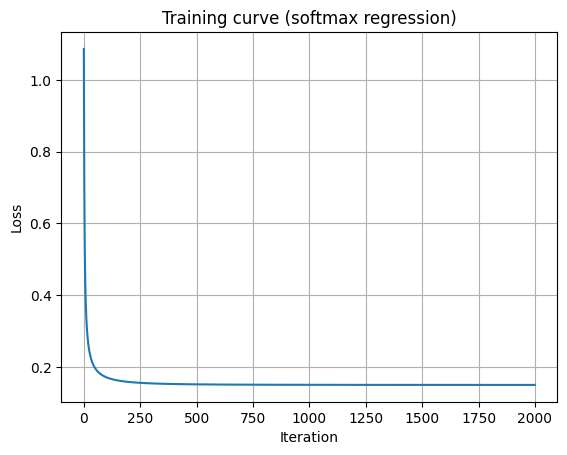

Macro-F1 on train: 0.952868447654036


In [13]:
model = SoftmaxRegressionGD(lr=0.3, n_iter=2000, tol=1e-10, seed=1, fit_intercept=True)
model.fit(X_syn, y_syn)

plt.figure()
plt.plot(model.loss_history_)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training curve (softmax regression)")
plt.grid(True)
plt.show()

y_hat = model.predict(X_syn)
print("Macro-F1 on train:", macro_f1(y_syn, y_hat, n_classes=3))


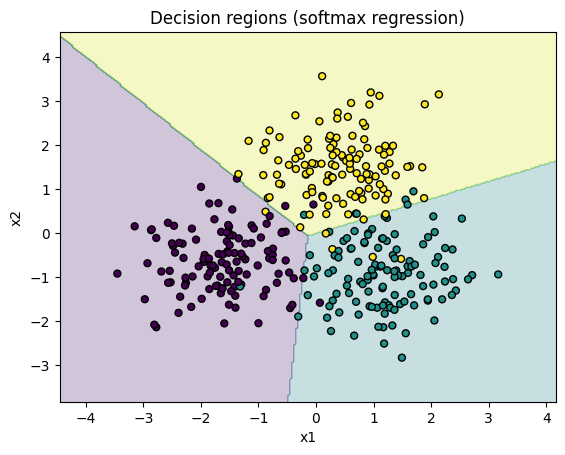

In [14]:
x1_min, x1_max = X_syn[:,0].min() - 1, X_syn[:,0].max() + 1
x2_min, x2_max = X_syn[:,1].min() - 1, X_syn[:,1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x1_min, x1_max, 250),
    np.linspace(x2_min, x2_max, 250),
)

grid = np.c_[xx.ravel(), yy.ravel()]
pred_grid = model.predict(grid).reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, pred_grid, alpha=0.25)
plt.scatter(X_syn[:,0], X_syn[:,1], c=y_syn, edgecolor="k", s=25)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Decision regions (softmax regression)")
plt.show()


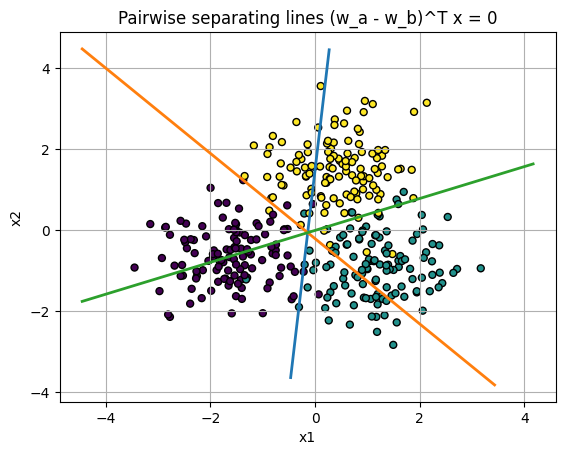

In [15]:
# границы между классами: (w_a - w_b)^T [1, x1, x2] = 0
W = model.W_  # (d+1, M) если fit_intercept=True

plt.figure()
plt.scatter(X_syn[:,0], X_syn[:,1], c=y_syn, edgecolor="k", s=25)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Pairwise separating lines (w_a - w_b)^T x = 0")
plt.grid(True)

x_line = np.linspace(x1_min, x1_max, 200)

for a in range(M):
    for b in range(a+1, M):
        wdiff = W[:, a] - W[:, b]   # (bias, w1, w2)
        # w0 + w1*x + w2*y = 0 -> y = -(w0 + w1*x)/w2
        if abs(wdiff[2]) > 1e-9:
            y_line = -(wdiff[0] + wdiff[1]*x_line) / wdiff[2]
            mask = (y_line >= x2_min) & (y_line <= x2_max)
            plt.plot(x_line[mask], y_line[mask], linewidth=2)

plt.show()


## Объяснение классификации

Для каждого класса $k$ модель вычисляет линейный скор $s_k(x)=w_k^\top x$.
Затем softmax переводит в вероятности $p_k(x)$.

Предсказание выбирается как класс с максимальной вероятностью, что эквивалентно
выбору максимального $s_k(x)$:

$$
\hat{y}(x)=\arg\max_k p_k(x)=\arg\max_k s_k(x).
$$

Граница между двумя классами $a$ и $b$ задаётся равенством их скоров:

$$
w_a^\top x = w_b^\top x
\quad\Leftrightarrow\quad
(w_a-w_b)^\top x = 0.
$$

В двумерном случае это прямые линии, разделяющие плоскость на области решений.
Свободный член (bias) сдвигает границы, а направления $w_k$ определяют, в какую сторону
возрастает вероятность соответствующего класса.
